<a href="https://colab.research.google.com/github/hamed/tabpfn-probes/blob/main/Thermodynamics_with_TabPFN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Can a Tabular Foundation Model Learn the Laws of Thermodynamics?
*Logistic regression and TabPFN look at the same data and disagree at absolute zero. One has the physics baked into its equation. The other, wisely, declines to guess.*


Nature has rules, and she's very strict about them. But what happens when you ask a blind mathematical black box—one that has never taken a physics class—to guess how the universe behaves?

Imagine a little particle, maybe a spin-½ sitting in a magnetic field. It's only got two choices: it can point up, or it can point down. That's it. A **two-state system**.

Now, how does Nature decide which state it's in? She uses a beautiful little rule called the Fermi-Dirac distribution. If the states are separated by some energy $\Delta E$, the chance of finding the particle in the higher state is
$$ P = \frac{1}{1 + e^{\beta \Delta E}} $$
where $\beta = 1/(k_B T)$ is just a fancy way of saying *how cold it is*. Inverse temperature.

Think about the extremes. When it's nice and hot ($\beta \Delta E \to 0$), everything is jiggling around. Both states are equally likely, and our **entropy**—a measure of how much we *don't* know—is at its maximum. Cool it way down and the jiggling stops. The system freezes into the lower state. Now we know exactly what state it's in, so the entropy *must* collapse to 0. Nature demands it.

**Here's the experiment:** We let a clever new tabular foundation model—[TabPFN](https://www.nature.com/articles/s41586-024-08328-6)—watch the system *only* at moderate temperatures ($|\beta \Delta E| < 4$). Then we ask it what happens at the extremes, where it has never seen data. Will it figure out that entropy must collapse to zero? Or will it shrug?

We'll compare it to plain logistic regression, which has a particular advantage we'll get to at the end.


In [ ]:
!pip install tabpfn_client --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.8/240.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
# Setup, imports, auth.
# Put your TabPFN token in Colab Secrets (key icon, left sidebar) as TABPFN_TOKEN.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tabpfn_client import TabPFNClassifier, set_access_token
from sklearn.linear_model import LogisticRegression

try:
    from google.colab import userdata
    token = userdata.get('TABPFN_TOKEN')
except Exception:
    token = os.environ.get('TABPFN_TOKEN', '')

if not token:
    raise RuntimeError(
        "No TabPFN token found. Add TABPFN_TOKEN to Colab Secrets "
        "(left sidebar -> key icon) or set the env var."
    )
set_access_token(token)


In [ ]:
def generate(x, seed=None):
    """Synthetic two-state thermodynamic system.

    Args:
        x: array of beta * Delta_E values.
        seed: optional RNG seed.

    Returns:
        DataFrame with x, sampled state y, and theoretical probabilities p0, p1.
    """
    rng = np.random.default_rng(seed)
    p1 = 1 / (1 + np.exp(-x))
    p0 = 1 - p1
    y  = rng.binomial(1, p1)
    return pd.DataFrame({"x": x, "y": y, "p0": p0, "p1": p1})

def entropy(p):
    """Shannon entropy in nats, summed over the last axis."""
    p = np.clip(p, 1e-300, 1.0)
    return -np.sum(p * np.log(p), axis=-1)

def fit_tabpfn(train, test):
    clf = TabPFNClassifier()
    clf.fit(train[['x']], train['y'])
    return entropy(clf.predict_proba(test[['x']]))

def fit_logistic(train, test):
    clf = LogisticRegression()
    clf.fit(train[['x']], train['y'])
    return entropy(clf.predict_proba(test[['x']]))


In [ ]:
# Big synthetic training pool. We'll restrict the visible range in a moment.
df_train = generate(np.random.uniform(-8, 8, 100_000), seed=0)

# Test grid spans the full range, including the extrapolation region.
df_test = generate(np.linspace(-8, 8, 101), seed=1)
df_test['S_theory'] = entropy(df_test[['p0', 'p1']].values)


## Restrict the model's view, then ask it about the extremes

We hide everything with $|\beta \Delta E| \geq 4$. The model only sees moderate temperatures. Then we evaluate it across the full range, including the cold regions it has never seen.

Three sample sizes for TabPFN (100, 1000, 10000) to check whether the problem is just lack of data. One logistic regression at the largest size, as a reference.


In [ ]:
train_restricted = df_train[df_train.x.abs() < 4]

df_test['S_100']      = fit_tabpfn(train_restricted.sample(100,    random_state=0), df_test)
df_test['S_1000']     = fit_tabpfn(train_restricted.sample(1000,   random_state=0), df_test)
df_test['S_10000']    = fit_tabpfn(train_restricted.sample(10000,  random_state=0), df_test)
df_test['S_logistic'] = fit_logistic(train_restricted.sample(10000, random_state=0), df_test)


00:02 Fitting... Done!
00:02 Predicting... Done!
00:02 Fitting... Done!
00:02 Predicting... Done!
00:02 Fitting... Done!
00:03 Predicting... Done!


## What does each model think the entropy looks like?

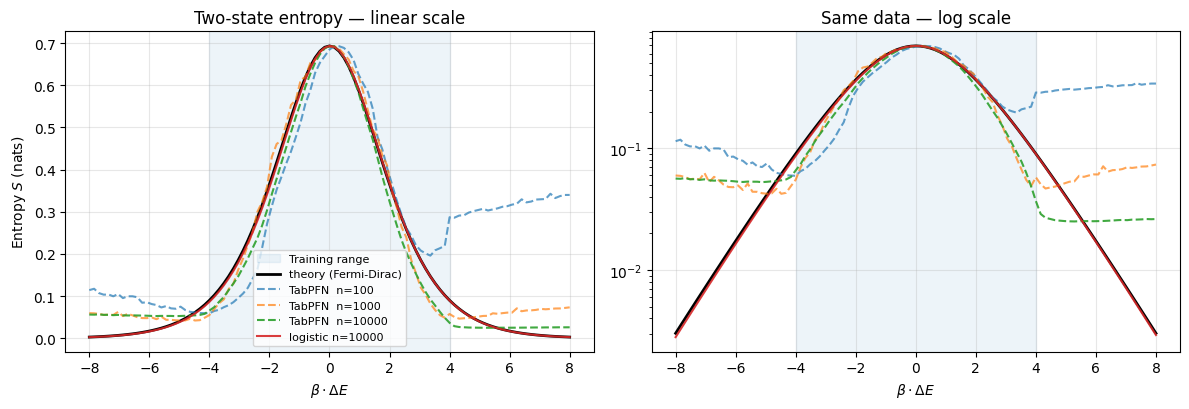

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)

for ax in axes:
    ax.axvspan(-4, 4, alpha=0.08, color="tab:blue", label="Training range")
    ax.plot(df_test.x, df_test.S_theory,   'k-',  label='theory (Fermi-Dirac)', lw=2)
    ax.plot(df_test.x, df_test.S_100,      '--',  label='TabPFN  n=100',   alpha=0.7)
    ax.plot(df_test.x, df_test.S_1000,     '--',  label='TabPFN  n=1000',  alpha=0.7)
    ax.plot(df_test.x, df_test.S_10000,    '--',  label='TabPFN  n=10000', alpha=0.9)
    ax.plot(df_test.x, df_test.S_logistic, '-',   label='logistic n=10000', alpha=0.9, color='tab:red')
    ax.set_xlabel(r"$\beta \cdot \Delta E$")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Entropy $S$ (nats)")
axes[0].set_title("Two-state entropy — linear scale")
axes[1].set_yscale("log")
axes[1].set_title("Same data — log scale")
axes[0].legend(fontsize=8, loc='lower center')

plt.tight_layout()
plt.show()


## More data does *not* fix it

The plot already tells the story, but let's put numbers on it. At $|\beta \Delta E| = 8$, Nature says the entropy is essentially zero. What does each model say?


In [ ]:
extreme = df_test[df_test.x.abs() > 7]

rows = [
    ("theory (Fermi-Dirac)",   extreme.S_theory.max()),
    ("logistic regression",    extreme.S_logistic.max()),
    ("TabPFN  n=100",          extreme.S_100.max()),
    ("TabPFN  n=1000",         extreme.S_1000.max()),
    ("TabPFN  n=10000",        extreme.S_10000.max()),
]

print(f"Maximum entropy in the extrapolation region (|beta*dE| > 7):\n")
print(f"  {'model':<24}  {'S (nats)':>12}   ratio vs theory")
print(f"  {'-'*24}  {'-'*12}   ---------------")
S_th = rows[0][1]
for name, S in rows:
    ratio = S / S_th if S_th > 0 else float('inf')
    print(f"  {name:<24}  {S:>12.3e}   {ratio:>10.0f}x")


Maximum entropy in the extrapolation region (|beta*dE| > 7):

  model                         S (nats)   ratio vs theory
  ------------------------  ------------   ---------------
  theory (Fermi-Dirac)         7.038e-03            1x
  logistic regression          6.856e-03            1x
  TabPFN  n=100                3.427e-01           49x
  TabPFN  n=1000               7.349e-02           10x
  TabPFN  n=10000              5.683e-02            8x


## Conclusion: inductive bias is a feature, not a bug

Two things happened here, and they're both worth taking seriously.

**Logistic regression nailed it.** Even far outside the data, it predicted that the entropy collapses to zero. Not because it studied physics, but because its functional form—the sigmoid—is *exactly* the Fermi-Dirac distribution. Its inductive bias and Nature's law are the same equation. When the math matches the physics, you get free extrapolation.

**TabPFN refused to extrapolate.** Push it past the training range and the predicted entropy flattens out instead of collapsing. More data doesn't help: n=100, n=1000, n=10000 all converge to the same wrong tails. This is not a sample-size problem. It's an out-of-distribution problem.

But here's the part that matters: **TabPFN's wrong answer is the *honest* wrong answer**. It hasn't memorized a physical law it was never told about. When it's outside its training distribution, it defaults to "I'm not sure", not to a confidently wrong extrapolation. For physics, where we *do* know the law and want extrapolation, that's a limitation. For the messy real-world tabular problems TabPFN was built for—where you usually don't know if you're inside or outside the support of your training data—graceful uncertainty in the tails is exactly the property you want.

The right tool depends on whether you know Nature's rule before you start. If you do, encode it. If you don't, a model that abstains beats one that confabulates.
